# EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual preferences for your notebook
sns.set_theme(style="darkgrid")
%matplotlib inline

# Load the raw transaction data (replace with your local file path)
df_raw = pd.read_csv("fraud.csv")

# Quick structural inspection
print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (594643, 10)


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [3]:
print("=== Cardinality & Constant Value Audit ===")
# 1. Check how many unique values exist in these columns
for col in ['zipcodeOri', 'zipMerchant', 'merchant', 'customer']:
    if col in df_raw.columns:
        unique_count = df_raw[col].nunique()
        print(f"Column '{col}' has {unique_count} unique value(s).")

print("\n=== Redundancy Audit ===")
# 2. Check if the origin zip and merchant zip are identical across all rows
if 'zipcodeOri' in df_raw.columns and 'zipMerchant' in df_raw.columns:
    are_identical = df_raw['zipcodeOri'].equals(df_raw['zipMerchant'])
    print(f"Are 'zipcodeOri' and 'zipMerchant' exactly identical? {are_identical}")

=== Cardinality & Constant Value Audit ===
Column 'zipcodeOri' has 1 unique value(s).
Column 'zipMerchant' has 1 unique value(s).
Column 'merchant' has 50 unique value(s).
Column 'customer' has 4112 unique value(s).

=== Redundancy Audit ===
Are 'zipcodeOri' and 'zipMerchant' exactly identical? True


In [4]:
print("=== Data Types and Standard Missing Values ===")
print(df_raw.info())

print("\n=== Missing Data Audit ===")
explicit_nulls = df_raw.isnull().sum()
print("Explicit NaNs per column:\n", explicit_nulls)

# Audit data-specific placeholder tokens ('U' for Unknown)
for col in ['age', 'gender']:
    if col in df_raw.columns:
        u_count = (df_raw[col] == "'U'").sum()
        print(f"Column '{col}' contains {u_count} implicit 'Unknown (U)' placeholders.")

=== Data Types and Standard Missing Values ===
<class 'pandas.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  str    
 2   age          594643 non-null  str    
 3   gender       594643 non-null  str    
 4   zipcodeOri   594643 non-null  str    
 5   merchant     594643 non-null  str    
 6   zipMerchant  594643 non-null  str    
 7   category     594643 non-null  str    
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 45.4 MB
None

=== Missing Data Audit ===
Explicit NaNs per column:
 step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64
Column 'age' contains 1178 implicit

=== Target Distribution ===
Benign (0): 587443 transactions (98.7892%)
Fraudulent (1): 7200 transactions (1.2108%)


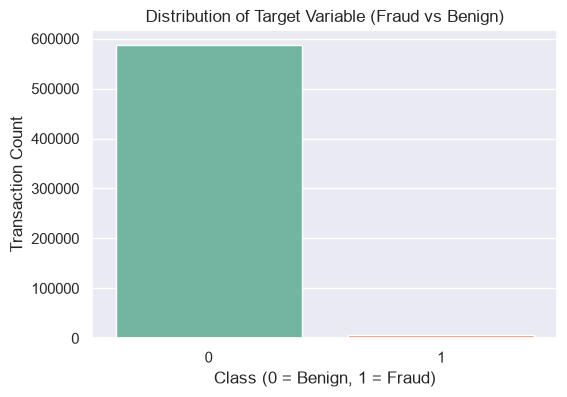

In [5]:
print("=== Target Distribution ===")
fraud_counts = df_raw['fraud'].value_counts()
fraud_percentages = df_raw['fraud'].value_counts(normalize=True) * 100

for cls in fraud_counts.index:
    label = "Fraudulent (1)" if cls == 1 else "Benign (0)"
    print(f"{label}: {fraud_counts[cls]} transactions ({fraud_percentages[cls]:.4f}%)")

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='fraud', data=df_raw, hue='fraud', palette='Set2', legend=False)
plt.title("Distribution of Target Variable (Fraud vs Benign)")
plt.ylabel("Transaction Count")
plt.xlabel("Class (0 = Benign, 1 = Fraud)")
plt.show()

=== Numerical Summary Stats ===
              amount
count  594643.000000
mean       37.890135
std       111.402831
min         0.000000
25%        13.740000
50%        26.900000
75%        42.540000
max      8329.960000


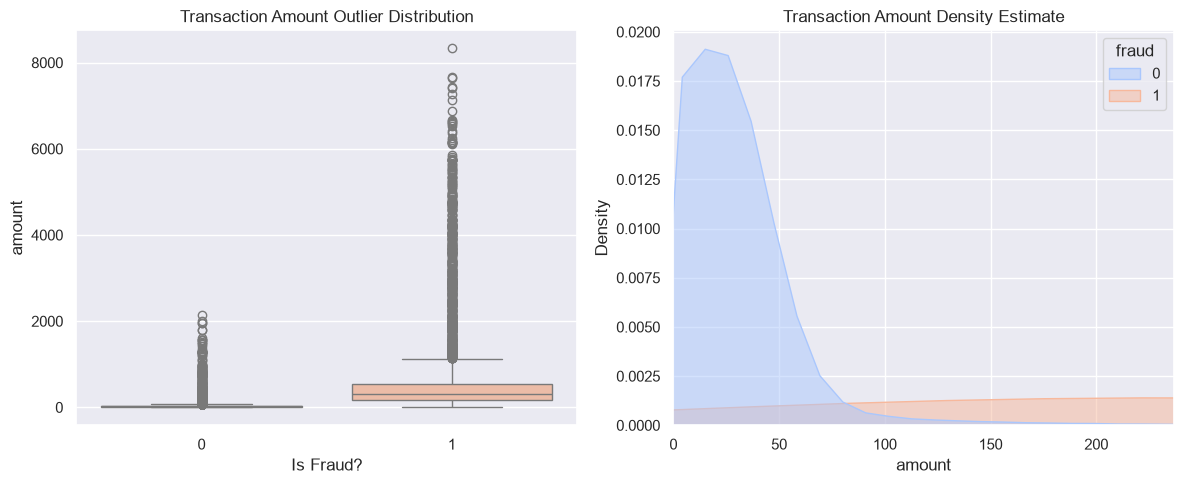

In [6]:
print("=== Numerical Summary Stats ===")
print(df_raw[['amount']].describe())

# Plotting the distribution of purchase amounts by fraud class
plt.figure(figsize=(12, 5))

# Subplot 1: Boxplot to clearly spot extreme outliers
plt.subplot(1, 2, 1)
sns.boxplot(x='fraud', y='amount', data=df_raw, hue='fraud', palette='coolwarm', legend=False)
plt.title("Transaction Amount Outlier Distribution")
plt.xlabel("Is Fraud?")

# Subplot 2: Kernel Density Estimate (KDE) to see distribution shapes
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_raw, x='amount', hue='fraud', fill=True, common_norm=False, palette='coolwarm', alpha=0.5)
plt.title("Transaction Amount Density Estimate")
plt.xlim(0, df_raw['amount'].quantile(0.99)) # Clip view to 99th percentile to see past massive outliers
plt.tight_layout()
plt.show()

=== Top 5 Highest Risk Categories ===
                    count      mean  Fraud_Probability_%
category                                                
'es_leisure'          499  0.949900            94.989980
'es_travel'           728  0.793956            79.395604
'es_sportsandtoys'   4002  0.495252            49.525237
'es_hotelservices'   1744  0.314220            31.422018
'es_otherservices'    912  0.250000            25.000000


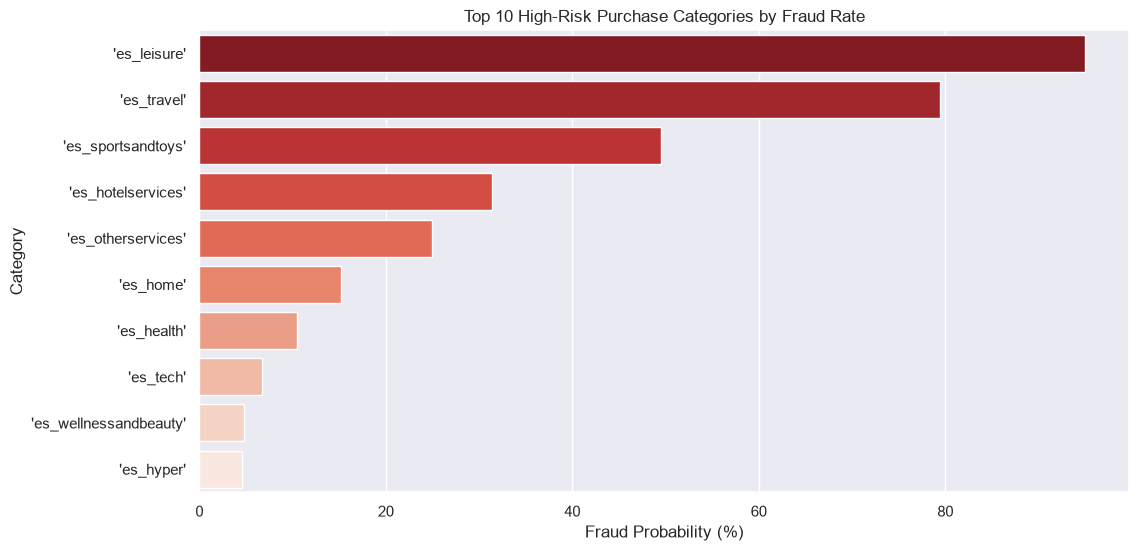

In [7]:
# Calculate the percentage probability of fraud for each purchase category
category_risk = df_raw.groupby('category')['fraud'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
category_risk['Fraud_Probability_%'] = category_risk['mean'] * 100

print("=== Top 5 Highest Risk Categories ===")
print(category_risk.head(5))

# Plotting Category Risk Matrix
plt.figure(figsize=(12, 6))
sns.barplot(
    x=category_risk['Fraud_Probability_%'].head(10), 
    y=category_risk.head(10).index, 
    hue=category_risk.head(10).index,
    palette='Reds_r',
    legend=False
)
plt.title("Top 10 High-Risk Purchase Categories by Fraud Rate")
plt.xlabel("Fraud Probability (%)")
plt.ylabel("Category")
plt.show()

# FEATURE ENGINEERING

In [8]:
print("=== Phase 2.5: Feature Engineering ===")

# 1. Time-Series Engineering
# Extracting the cyclical time loops from the linear 'step' column
df_raw['HourOfDay'] = df_raw['step'] % 24
df_raw['DayOfWeek'] = (df_raw['step'] // 24) % 7

# 2. Contextual Spending Engineering
# Calculate the average amount for each category and divide the current row's amount by it
category_avg = df_raw.groupby('category')['amount'].transform('mean')
df_raw['Amount_to_Category_Avg'] = df_raw['amount'] / (category_avg + 0.0001) # 0.0001 prevents division by zero errors

# Calculate the average amount for each specific customer
customer_avg = df_raw.groupby('customer')['amount'].transform('mean')
df_raw['Amount_to_Customer_Avg'] = df_raw['amount'] / (customer_avg + 0.0001)

# 3. Behavioral Velocity
# Count the total number of transactions linked to each customer ID
df_raw['Customer_Transaction_Frequency'] = df_raw.groupby('customer')['step'].transform('count')

# Count the total number of transactions linked to each merchant ID
df_raw['Merchant_Popularity'] = df_raw.groupby('merchant')['step'].transform('count')

print("Successfully engineered 6 new features!")
print(f"Total columns in dataset now: {df_raw.shape[1]}")
df_raw.head()

=== Phase 2.5: Feature Engineering ===
Successfully engineered 6 new features!
Total columns in dataset now: 16


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,HourOfDay,DayOfWeek,Amount_to_Category_Avg,Amount_to_Customer_Avg,Customer_Transaction_Frequency,Merchant_Popularity
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0,0,0,0.168779,0.161114,167,205426
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0,0,0,1.471904,1.214887,169,205426
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0,0,0,0.997467,0.648831,65,299693
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0,0,0,0.639877,0.568578,171,205426
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0,0,0,1.325010,1.126926,145,205426


# DATASET SPLITTING

In [9]:
from sklearn.model_selection import train_test_split

print("=== Phase 3: Dataset Splitting (Stratified) ===")

# 1. Isolate the target variable
y = df_raw['fraud']

# 2. Define the features by dropping the target and the useless EDA columns
cols_to_drop = ['fraud', 'zipcodeOri', 'zipMerchant', 'customer', 'merchant', 'step']
X = df_raw.drop(columns=cols_to_drop)

# 3. Execute the Stratified Split (80% Training / 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,       # Reserves 20% of the data for unseen testing
    random_state=42,     # Locks the random seed for reproducible results
    stratify=y           # CRITICAL: Preserves the 1.21% target imbalance across both sets
)

# 4. Verify the integrity of the split
print(f"Original Dataset Size: {df_raw.shape[0]} rows")
print(f"Training Set Size:   {X_train.shape[0]} rows")
print(f"Testing Set Size:    {X_test.shape[0]} rows")

print("\n=== Target Imbalance Verification ===")
print(f"Training Fraud Rate: {y_train.value_counts(normalize=True)[1] * 100:.4f}%")
print(f"Testing Fraud Rate:  {y_test.value_counts(normalize=True)[1] * 100:.4f}%")

=== Phase 3: Dataset Splitting (Stratified) ===
Original Dataset Size: 594643 rows
Training Set Size:   475714 rows
Testing Set Size:    118929 rows

=== Target Imbalance Verification ===
Training Fraud Rate: 1.2108%
Testing Fraud Rate:  1.2108%


# DATA TRANSFORMATION (ENCODING AND SCALING)

In [10]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler

print("=== Phase 4: Data Transformation ===")

# 1. Define the column groups
# We ignore 'step', 'Customer', and 'Merchant' as they are structural IDs or raw time
categorical_cols = ['age', 'gender', 'category']
numerical_cols = [
    'amount', 
    'HourOfDay', 
    'DayOfWeek', 
    'Amount_to_Category_Avg', 
    'Amount_to_Customer_Avg', 
    'Customer_Transaction_Frequency', 
    'Merchant_Popularity'
]

# 2. Initialize the Transformers
# handle_unknown='ignore' ensures the model won't crash if a completely new category appears later
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = RobustScaler()

# ---------------------------------------------------------
# 3. FIT AND TRANSFORM THE TRAINING DATA
# ---------------------------------------------------------
print("Fitting and transforming X_train...")

# Encode Categorical
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
df_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)

# Scale Numerical
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
df_train_scaled = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)

# Combine into final clean Training Set
X_train_clean = pd.concat([df_train_scaled, df_train_encoded], axis=1)

# ---------------------------------------------------------
# 4. STRICTLY TRANSFORM THE TESTING DATA
# ---------------------------------------------------------
print("Transforming X_test (No fitting!)...")

# Apply frozen rules to Test set
X_test_encoded = encoder.transform(X_test[categorical_cols])
df_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

X_test_scaled = scaler.transform(X_test[numerical_cols])
df_test_scaled = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

# Combine into final clean Testing Set
X_test_clean = pd.concat([df_test_scaled, df_test_encoded], axis=1)

print("\n=== Transformation Complete ===")
print(f"Clean Training Data Shape: {X_train_clean.shape}")
print(f"Clean Testing Data Shape:  {X_test_clean.shape}")
X_train_clean.head()

=== Phase 4: Data Transformation ===
Fitting and transforming X_train...
Transforming X_test (No fitting!)...

=== Transformation Complete ===
Clean Training Data Shape: (475714, 34)
Clean Testing Data Shape:  (118929, 34)


,amount,HourOfDay,DayOfWeek,Amount_to_Category_Avg,Amount_to_Customer_Avg,Customer_Transaction_Frequency,Merchant_Popularity,age_'0',age_'1',age_'2',...,category_'es_home',category_'es_hotelservices',category_'es_hyper',category_'es_leisure',category_'es_otherservices',category_'es_sportsandtoys',category_'es_tech',category_'es_transportation',category_'es_travel',category_'es_wellnessandbeauty'
296209,-0.274053,-0.833333,0.25,-0.210385,-0.355460,0.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
329958,0.002779,0.000000,0.25,0.096154,0.171107,0.523810,-1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
394447,-0.149357,-0.500000,0.50,-0.072308,-0.015933,-0.095238,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
588673,-0.682529,-0.083333,-0.75,-0.662692,-0.844429,4.000000,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
139286,-0.294547,-0.833333,-0.25,-0.233077,-0.147756,0.285714,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# CLASS IMBALANCE

In [11]:
from imblearn.over_sampling import SMOTE

print("=== Phase 5: Handling Class Imbalance ===")

# 1. Initialize SMOTE
# random_state ensures the synthetic data is generated exactly the same way every time
smote = SMOTE(random_state=42)

# 2. Fit and resample strictly on the TRAINING data
# We pass in the fully cleaned, encoded, and scaled training matrices from Phase 4
print("Generating synthetic fraudulent transactions...")
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_clean, y_train)

# 3. Verify the new class distributions
print("\n=== Original Training Split ===")
print(y_train.value_counts())

print("\n=== SMOTE Balanced Training Split ===")
print(y_train_balanced.value_counts())

# 4. Final Sanity Check on the Testing Data
print("\n=== Untouched Testing Split (Real World Simulation) ===")
print(y_test.value_counts())

=== Phase 5: Handling Class Imbalance ===
Generating synthetic fraudulent transactions...

=== Original Training Split ===
fraud
0    469954
1      5760
Name: count, dtype: int64

=== SMOTE Balanced Training Split ===
fraud
0    469954
1    469954
Name: count, dtype: int64

=== Untouched Testing Split (Real World Simulation) ===
fraud
0    117489
1      1440
Name: count, dtype: int64


# TRAINING

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import time

print("=== Final Training: XGBoost ===")

CUSTOM_THRESHOLD = 0.9  # Change this value to adjust the model's strictness

# 1. PASTE YOUR WINNING FEATURES FOR XGBOOST HERE
xgb_features = [
    "amount",
    "HourOfDay",
    "DayOfWeek",
    "Amount_to_Customer_Avg",
    "Merchant_Popularity",
    "age_'2'",
    "age_'4'",
    "gender_'U'",
    "category_'es_barsandrestaurants'",
    "category_'es_fashion'",
    "category_'es_food'",
    "category_'es_hyper'",
    "category_'es_sportsandtoys'",
    "category_'es_transportation'",
    "category_'es_wellnessandbeauty'"
]

# 2. Slice the Datasets
print(f"Slicing dataset to {len(xgb_features)} features...")
X_train_xgb = X_train_balanced[xgb_features]
X_test_xgb = X_test_clean[xgb_features]

# 3. Initialize and Train
xgb_model = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    learning_rate=0.1, 
    n_jobs=-1, 
    eval_metric='logloss'
)

print("Training XGBoost...")
start_time = time.time()
xgb_model.fit(X_train_xgb, y_train_balanced)
print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

# 4. Generate Predictions and Evaluate
# Extract the raw probabilities for Class 1 (Fraud)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Apply the manual threshold rule
y_pred_xgb = (y_pred_proba_xgb >= CUSTOM_THRESHOLD).astype(int)

print("\n--- XGBoost Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}\n")

# 5. Display the Confusion Matrix Numbers
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix Breakdown:")
print(f"True Negatives (Correctly Passed):   {cm_xgb[0][0]}")
print(f"False Positives (Accidental Blocks): {cm_xgb[0][1]}")
print(f"False Negatives (Missed Fraud):      {cm_xgb[1][0]}")
print(f"True Positives (Caught Fraud):       {cm_xgb[1][1]}")

=== Final Training: XGBoost ===
Slicing dataset to 15 features...
Training XGBoost...
Training completed in 3.14 seconds.

--- XGBoost Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117489
           1       0.86      0.76      0.81      1440

    accuracy                           1.00    118929
   macro avg       0.93      0.88      0.90    118929
weighted avg       1.00      1.00      1.00    118929

AUC-ROC Score: 0.9972

Confusion Matrix Breakdown:
True Negatives (Correctly Passed):   117315
False Positives (Accidental Blocks): 174
False Negatives (Missed Fraud):      351
True Positives (Caught Fraud):       1089


# JOBLIB IMPORTING

In [24]:
import joblib

print("=== Exporting Production Artifacts ===")

# 1. Export the Model and Scaler
joblib.dump(xgb_model, 'xgboost_model_v1.pkl')

# 1. Define the exact 5 continuous features in a strict order
numerical_cols = [
    "amount", 
    "HourOfDay", 
    "DayOfWeek", 
    "Amount_to_Customer_Avg", 
    "Merchant_Popularity"
]

# 2. Train the scaler on just these 5 columns from your training data
numerical_scaler = RobustScaler()
numerical_scaler.fit(X_train[numerical_cols])

# 3. Export the new artifact
joblib.dump(numerical_scaler, 'numerical_scaler.pkl')
print("5-Feature numerical scaler exported successfully!")

# 2. Calculate Historical Dictionaries from the ORIGINAL DataFrame
# Customer Average Spending
customer_avg_series = df_raw.groupby('customer')['amount'].mean()
joblib.dump(customer_avg_series.to_dict(), 'customer_averages.pkl')

# Merchant Popularity (Transaction count per merchant)
merchant_pop_series = df_raw.groupby('merchant').size() # .size() counts the occurrences
joblib.dump(merchant_pop_series.to_dict(), 'merchant_popularity.pkl')

print("All artifacts exported successfully for the API!")

=== Exporting Production Artifacts ===
5-Feature numerical scaler exported successfully!
All artifacts exported successfully for the API!


# FRAUD CASES

In [26]:
# 1. Filter for confirmed fraud
fraud_df = df_raw[df_raw['fraud'] == 1].copy()

# 2. Pick the first row and format it as a dictionary
true_fraud = fraud_df.iloc[4]

print("=== Paste this JSON into your API ===")
print({
    "step": int(true_fraud['step']),
    "customer_id": str(true_fraud['customer']),
    "zipcode_origin": "28007",
    "merchant_id": str(true_fraud['merchant']),
    "zip_merchant": "28007",
    "age": str(true_fraud['age']),
    "gender": str(true_fraud['gender']),
    "category": str(true_fraud['category']),
    "amount": float(true_fraud['amount'])
})

=== Paste this JSON into your API ===
{'step': 0, 'customer_id': "'C1450140987'", 'zipcode_origin': '28007', 'merchant_id': "'M1198415165'", 'zip_merchant': '28007', 'age': "'4'", 'gender': "'F'", 'category': "'es_wellnessandbeauty'", 'amount': 220.11}


In [14]:
# from sklearn.feature_selection import SequentialFeatureSelector
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split
# import time

# print("=== Phase 5.5: Forward Feature Selection (SFS) ===")

# # 1. Create a Miniaturized Training Set for SFS (5% of 940,000 = ~47,000 rows)
# # We stratify to ensure the 50/50 SMOTE balance remains perfectly intact
# X_train_sample, _, y_train_sample, _ = train_test_split(
#     X_train_balanced, 
#     y_train_balanced, 
#     train_size=0.05, 
#     random_state=42, 
#     stratify=y_train_balanced
# )

# print(f"Running Feature Selection on {len(X_train_sample)} rows to save computational time...\n")

# # 2. Initialize lightweight versions of our three candidate models 
# # (We reduce trees/depth slightly just to make the SFS loop run faster)
# models_to_test = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
#     "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
#     "XGBoost": XGBClassifier(n_estimators=50, max_depth=5, random_state=42, eval_metric='logloss')
# }

# # 3. Loop through each model, run SFS, and extract the Top 15 features
# for model_name, model in models_to_test.items():
#     print(f"--- Drafting Top 15 Features for {model_name} ---")
#     start_time = time.time()
    
#     # Initialize SFS: We force it to pick exactly the 15 best features using 3-Fold Cross Validation
#     sfs = SequentialFeatureSelector(
#         estimator=model, 
#         n_features_to_select=15, 
#         direction='forward', 
#         cv=3, 
#         n_jobs=-1 # Uses all CPU cores to speed up the cross-validation
#     )
    
#     # Fit SFS on the subsample
#     sfs.fit(X_train_sample, y_train_sample)
    
#     # Extract the names of the winning columns
#     selected_features = X_train_sample.columns[sfs.get_support()]
    
#     print(f"SFS completed in {(time.time() - start_time):.2f} seconds.")
#     print("Winning Features:")
#     for feature in selected_features:
#         print(f" - {feature}")
#     print("\n")



In [15]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
# import time

# print("=== Final Training: Random Forest ===")

# # 1. PASTE YOUR WINNING FEATURES FOR RANDOM FOREST HERE
# rf_features = [
#     "Amount_to_Category_Avg",
#     "Customer_Transaction_Frequency",
#     "Merchant_Popularity",
#     "age_'0'",
#     "age_'2'",
#     "gender_'M'",
#     "category_'es_barsandrestaurants'",
#     "category_'es_contents'",
#     "category_'es_fashion'",
#     "category_'es_health'",
#     "category_'es_hotelservices'",
#     "category_'es_hyper'",
#     "category_'es_sportsandtoys'",
#     "category_'es_tech'",
#     "category_'es_wellnessandbeauty'"
# ]

# # 2. Slice the Datasets
# print(f"Slicing dataset to {len(rf_features)} features...")
# X_train_rf = X_train_balanced[rf_features]
# X_test_rf = X_test_clean[rf_features]

# # 3. Initialize and Train
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# print("Training Random Forest...")
# start_time = time.time()
# rf_model.fit(X_train_rf, y_train_balanced)
# print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

# # 4. Generate Predictions and Evaluate
# y_pred_rf = rf_model.predict(X_test_rf)
# y_pred_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

# print("\n--- Random Forest Evaluation ---")
# print("Classification Report:")
# print(classification_report(y_test, y_pred_rf))

# print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}\n")

# # 5. Display the Confusion Matrix Numbers
# cm_rf = confusion_matrix(y_test, y_pred_rf)
# print("Confusion Matrix Breakdown:")
# print(f"True Negatives (Correctly Passed):   {cm_rf[0][0]}")
# print(f"False Positives (Accidental Blocks): {cm_rf[0][1]}")
# print(f"False Negatives (Missed Fraud):      {cm_rf[1][0]}")
# print(f"True Positives (Caught Fraud):       {cm_rf[1][1]}")

In [16]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
# import time

# print("=== Final Training: Logistic Regression ===")

# # 1. PASTE YOUR WINNING FEATURES FOR LOGISTIC REGRESSION HERE
# log_features = [
#     "amount",
#     "Amount_to_Customer_Avg",
#     "Customer_Transaction_Frequency",
#     "Merchant_Popularity",
#     "age_'2'",
#     "age_'4'",
#     "age_'6'",
#     "gender_'M'",
#     "category_'es_contents'",
#     "category_'es_fashion'",
#     "category_'es_home'",
#     "category_'es_leisure'",
#     "category_'es_sportsandtoys'",
#     "category_'es_tech'",
#     "category_'es_wellnessandbeauty'"
# ]

# # 2. Slice the Datasets
# print(f"Slicing dataset to {len(log_features)} features...")
# X_train_log = X_train_balanced[log_features]
# X_test_log = X_test_clean[log_features]

# # 3. Initialize and Train
# log_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

# print("Training Logistic Regression...")
# start_time = time.time()
# log_model.fit(X_train_log, y_train_balanced)
# print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

# # 4. Generate Predictions and Evaluate
# y_pred_log = log_model.predict(X_test_log)
# y_pred_proba_log = log_model.predict_proba(X_test_log)[:, 1]

# print("\n--- Logistic Regression Evaluation ---")
# print("Classification Report:")
# print(classification_report(y_test, y_pred_log))

# print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_proba_log):.4f}\n")

# # 5. Display the Confusion Matrix Numbers
# cm_log = confusion_matrix(y_test, y_pred_log)
# print("Confusion Matrix Breakdown:")
# print(f"True Negatives (Correctly Passed):   {cm_log[0][0]}")
# print(f"False Positives (Accidental Blocks): {cm_log[0][1]}")
# print(f"False Negatives (Missed Fraud):      {cm_log[1][0]}")
# print(f"True Positives (Caught Fraud):       {cm_log[1][1]}")

In [17]:
# from sklearn.ensemble import RandomForestClassifier
# import time

# print("=== Phase 6: Model Training (Random Forest) ===")

# # 1. Initialize the Algorithm
# rf_model = RandomForestClassifier(
#     n_estimators=100,    # The number of decision trees in the forest
#     random_state=42,     # Locks the random seed for reproducible results
#     n_jobs=-1            # CRITICAL: -1 tells the model to use ALL available CPU cores
# )

# # 2. Train the Model on the SMOTE Balanced Data
# print("Training the Random Forest on ~940,000 balanced rows...")
# print("(This may take a couple of minutes depending on your CPU. Grab a coffee!)")

# start_time = time.time()

# # We strictly feed it the balanced training data, completely hiding the test set
# rf_model.fit(X_train_balanced, y_train_balanced)

# end_time = time.time()
# print(f"Training successfully completed in {(end_time - start_time):.2f} seconds!")

In [18]:
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# import seaborn as sns
# import matplotlib.pyplot as plt

# print("=== Phase 7: Model Evaluation (Testing Data) ===")

# # 1. Generate Predictions
# # .predict() outputs a hard 0 or 1 (Benign or Fraud)
# y_pred = rf_model.predict(X_test_clean)

# # .predict_proba() outputs the exact percentage confidence (e.g., 85% sure this is fraud)
# # We specifically slice [:, 1] to get the probability of class 1 (Fraud)
# y_pred_proba = rf_model.predict_proba(X_test_clean)[:, 1]

# # 2. Text Report for Precision, Recall, and F1-Score
# print("Classification Report:")
# print(classification_report(y_test, y_pred))

# # 3. Calculate AUC-ROC
# auc_score = roc_auc_score(y_test, y_pred_proba)
# print(f"AUC-ROC Score: {auc_score:.4f}\n")


In [19]:
# from xgboost import XGBClassifier
# from sklearn.metrics import roc_auc_score
# import time

# print("=== Phase 8: Model Training Challenger (XGBoost) ===")

# # 1. Initialize the XGBoost Algorithm
# xgb_model = XGBClassifier(
#     n_estimators=100,      # Same number of trees as Random Forest for a fair fight
#     random_state=42,       # Locked seed
#     n_jobs=-1,             # Use all CPU cores
#     learning_rate=0.1,     # Controls how aggressively it corrects previous mistakes
#     eval_metric='logloss'  # Standard evaluation metric for XGBoost
# )

# # 2. Train the Model (Using the same SMOTE balanced data)
# print("Training XGBoost on ~940,000 balanced rows...")
# start_time = time.time()
# xgb_model.fit(X_train_balanced, y_train_balanced)
# print(f"Training completed in {(time.time() - start_time):.2f} seconds!")

# # 3. Generate Predictions on the untouched Test Set
# y_pred_xgb = xgb_model.predict(X_test_clean)
# y_pred_proba_xgb = xgb_model.predict_proba(X_test_clean)[:, 1]

# # 4. Evaluate the Challenger
# print("\n=== XGBoost Evaluation (Testing Data) ===")
# print("Classification Report:")
# print(classification_report(y_test, y_pred_xgb))

# auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
# print(f"AUC-ROC Score: {auc_score_xgb:.4f}")

In [20]:
# from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

# print("=== Phase 8b: Threshold Tuning (XGBoost) ===")

# # 1. Define the list of strict thresholds to test
# thresholds = [0.50, 0.80, 0.90, 0.95, 0.99]

# print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'False Positives (Blocked Innocents)'}")
# print("-" * 80)

# best_f1 = 0
# best_threshold = 0

# # 2. Loop through each threshold and calculate the metrics
# for thresh in thresholds:
#     # Apply the specific rule
#     y_pred_custom = (y_pred_proba_xgb >= thresh).astype(int)
    
#     # Calculate metrics specifically for Class 1 (Fraud)
#     precision = precision_score(y_test, y_pred_custom)
#     recall = recall_score(y_test, y_pred_custom)
#     f1 = f1_score(y_test, y_pred_custom)
    
#     # Get False Positives from the confusion matrix
#     cm = confusion_matrix(y_test, y_pred_custom)
#     false_positives = cm[0][1]
    
#     print(f"{thresh * 100:>5.0f}%     | {precision:<10.4f} | {recall:<10.4f} | {f1:<10.4f} | {false_positives}")
    
#     # Track the best F1-score
#     if f1 > best_f1:
#         best_f1 = f1
#         best_threshold = thresh

# print("-" * 80)
# print(f"\nThe optimal threshold for maximizing F1-Score is: {best_threshold * 100}%")

In [21]:
# from lazypredict.Supervised import LazyClassifier
# from sklearn.model_selection import train_test_split
# import time

# print("=== Phase 9: AutoML Benchmarking (Lazy Predict) ===")

# # 1. Create a Miniaturized Training Set (5% of 940,000 = ~47,000 rows)
# # We strictly stratify by y_train_balanced to keep the perfect 50/50 SMOTE ratio
# X_train_sample, _, y_train_sample, _ = train_test_split(
#     X_train_balanced, 
#     y_train_balanced, 
#     train_size=0.05, 
#     random_state=42, 
#     stratify=y_train_balanced
# )

# # 2. Create a Miniaturized Testing Set (10% of ~118,000 = ~11,800 rows)
# X_test_sample, _, y_test_sample, _ = train_test_split(
#     X_test_clean, 
#     y_test, 
#     train_size=0.10, 
#     random_state=42, 
#     stratify=y_test
# )

# print(f"Miniaturized Training Data: {len(X_train_sample)} rows")
# print(f"Miniaturized Testing Data:  {len(X_test_sample)} rows")
# print("\nInitializing 40+ models... (This will take a few minutes)")

# # 3. Initialize and Run Lazy Predict
# start_time = time.time()
# clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# # We fit it exclusively on the miniaturized samples
# models, predictions = clf.fit(X_train_sample, X_test_sample, y_train_sample, y_test_sample)

# print(f"\nBenchmarking completed in {(time.time() - start_time):.2f} seconds!")

# # 4. Display the Top 10 Models sorted strictly by F1-Score
# print("\n=== Top 10 Models by F1-Score ===")
# print(models.sort_values(by='F1 Score', ascending=False).head(10))

In [22]:
# from sklearn.linear_model import LogisticRegression

# print("=== Phase 10: Model Training Baseline (Logistic Regression) ===")

# # 1. Initialize the Logistic Regression Algorithm
# log_model = LogisticRegression(
#     max_iter=1000,       # Increased to ensure convergence on massive datasets
#     random_state=42,     # Locked seed for reproducibility
#     n_jobs=-1            # Use all available CPU cores
# )

# # 2. Train the Model on the SMOTE Balanced Data
# print("Training Logistic Regression on ~940,000 balanced rows...")
# start_time = time.time()
# log_model.fit(X_train_balanced, y_train_balanced)
# print(f"Training completed in {(time.time() - start_time):.2f} seconds!\n")

# # 3. Generate Predictions on the untouched Test Set
# y_pred_log = log_model.predict(X_test_clean)
# y_pred_proba_log = log_model.predict_proba(X_test_clean)[:, 1]

# # 4. Evaluate the Model
# print("=== Logistic Regression Evaluation (Testing Data) ===")
# print("Classification Report:")
# print(classification_report(y_test, y_pred_log))

# auc_score_log = roc_auc_score(y_test, y_pred_proba_log)
# print(f"AUC-ROC Score: {auc_score_log:.4f}\n")

# # 5. Display the Confusion Matrix Numbers
# cm_log = confusion_matrix(y_test, y_pred_log)
# print("Confusion Matrix Breakdown:")
# print(f"True Negatives (Correctly Passed):   {cm_log[0][0]}")
# print(f"False Positives (Accidental Blocks): {cm_log[0][1]}")
# print(f"False Negatives (Missed Fraud):      {cm_log[1][0]}")
# print(f"True Positives (Caught Fraud):       {cm_log[1][1]}")